In [1]:
import sys
import os
import matplotlib.pyplot as plt
import networkx as nx
import json

# Add the parent directory to the path to import from src
sys.path.append(os.path.abspath(".."))
from concept_creator.critical_point_concept_service import (
    CriticalPointConceptService,
)

# Configuration
uri = "bolt://localhost:7687"
user = "neo4j"
password = "111122223333"
session_id = "3_1"
concept_name = session_id



In [2]:
# Create the concept with visualization
service = CriticalPointConceptService(uri, user, password)
concept_id, concept_graph = service.create_concept_incrementally(
    session_id, 
    concept_name, 
    steps=8,
    debug_mode=True
)

INFO:root:Initializing ConceptCreationRepository
INFO:root:Database connection established
INFO:concept_creator.critical_point_concept_service:CriticalPointConceptService initialized.
INFO:concept_creator.critical_point_concept_service:Creating concept for session 3_1 using Critical Point approach.
INFO:root:Getting image IDs for session 3_1
INFO:concept_creator.critical_point_concept_service:Initialized concept with graph from image c1270465-a551-46b8-917f-4b1196af8d08. Nodes: 19
INFO:concept_creator.critical_point_concept_service:Processing image 2/26: 0f3315f4-7d8d-4def-8916-444b9a6264d5
INFO:graph_minor_finder:Finding maximum common minor between graphs: concept (19 nodes) and image (19 nodes)
INFO:critical_point_preprocessor:Preprocessing graphs for critical point compatibility
INFO:critical_point_preprocessor:Graph1 critical points: {'IntersectionPoint': 1, 'CornerPoint': 2, 'EndPoint': 2, 'StartPoint': 1}
INFO:critical_point_preprocessor:Graph2 critical points: {'IntersectionPoi

In [3]:
def visualize_concept(concept_graph: nx.Graph):
    # Extract node positions from the graph
    pos = {}
    for node_id, node_data in concept_graph.nodes(data=True):
        # For regular points
        if 'x' in node_data and 'y' in node_data:
            x = node_data['x']['center']
            y = node_data['y']['center']
                
            pos[node_id] = (x, y)
            
        if 'labels' in node_data and 'Vector' in node_data['labels']:
                x1 = node_data['x1']
                x2 = node_data['x2']
                y1 = node_data['y1']
                y2 = node_data['y2']
                
                x1 = x1['center'] if isinstance(x1, dict) and 'center' in x1 else x1
                x2 = x2['center'] if isinstance(x2, dict) and 'center' in x2 else x2
                y1 = y1['center'] if isinstance(y1, dict) and 'center' in y1 else y1
                y2 = y2['center'] if isinstance(y2, dict) and 'center' in y2 else y2
                
                # Calculate midpoint for vectors
                pos[node_id] = ((x1 + x2) / 2, (y1 + y2) / 2)
    # Create figure
    plt.figure(figsize=(12, 10))
    
    node_to_color = {
        "IntersectionPoint": "red",
        "CornerPoint": "green",
        "EndPoint": "blue",
        "QuadrantChangePoint": "purple",
        "StartPoint": "orange"
    }
    # Draw nodes with colors based on their labels
    node_colors = []
    labels_for_nodes = {}
    for node_id in concept_graph.nodes():
        node_data = concept_graph.nodes[node_id]
        
        # Try to get labels from the node data
        labels = []
        if 'labels' in node_data:
            labels = node_data['labels']
            
        labels_for_nodes[node_id] = ', '.join(str(label) for label in labels) + ' ' + str(node_id.split(':')[-1])
        
        # Check if any label matches our color mapping
        color = 'lightblue'  # Default color
        for label in labels:
            label_str = str(label)  # Convert to string if it's not already
            if label_str in node_to_color:
                color = node_to_color[label_str]
                break
        
        node_colors.append(color)
        
    print(labels_for_nodes)
    # Draw the graph
    nx.draw_networkx_nodes(concept_graph, pos, node_color=node_colors, node_size=500)
    nx.draw_networkx_edges(concept_graph, pos, width=2, alpha=0.7, edge_color='gray')
    nx.draw_networkx_labels(concept_graph, pos, font_size=8, font_weight='bold', labels=labels_for_nodes)
    
    plt.title('Concept Graph Visualization')
    plt.axis('equal')  # Equal aspect ratio
    plt.grid(True)
    plt.gca().invert_yaxis()  # Invert y-axis to match image coordinates
    plt.tight_layout()
    
    # return plt.gcf()  # Return the figure for further customization if needed

{'4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2751': 'Point, StartPoint 2751', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3299': 'Vector 3299', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2611': 'Point 2611', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3298': 'Vector, HorizontalVector 3298', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2609': 'CornerPoint, Point 2609', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:1911': 'Vector 1911', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:71': 'IntersectionPoint, Point 71', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3086': 'Vector, HorizontalVector 3086', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2856': 'EndPoint, Point 2856', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:1912': 'Vector 1912', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:73': 'CornerPoint, Point 73', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3094': 'Vector, HorizontalVector 3094', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2602': 'Point 2602', '4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3096': 'Vector 3096', '4:9e1c8335-dc1b-46bc-b81

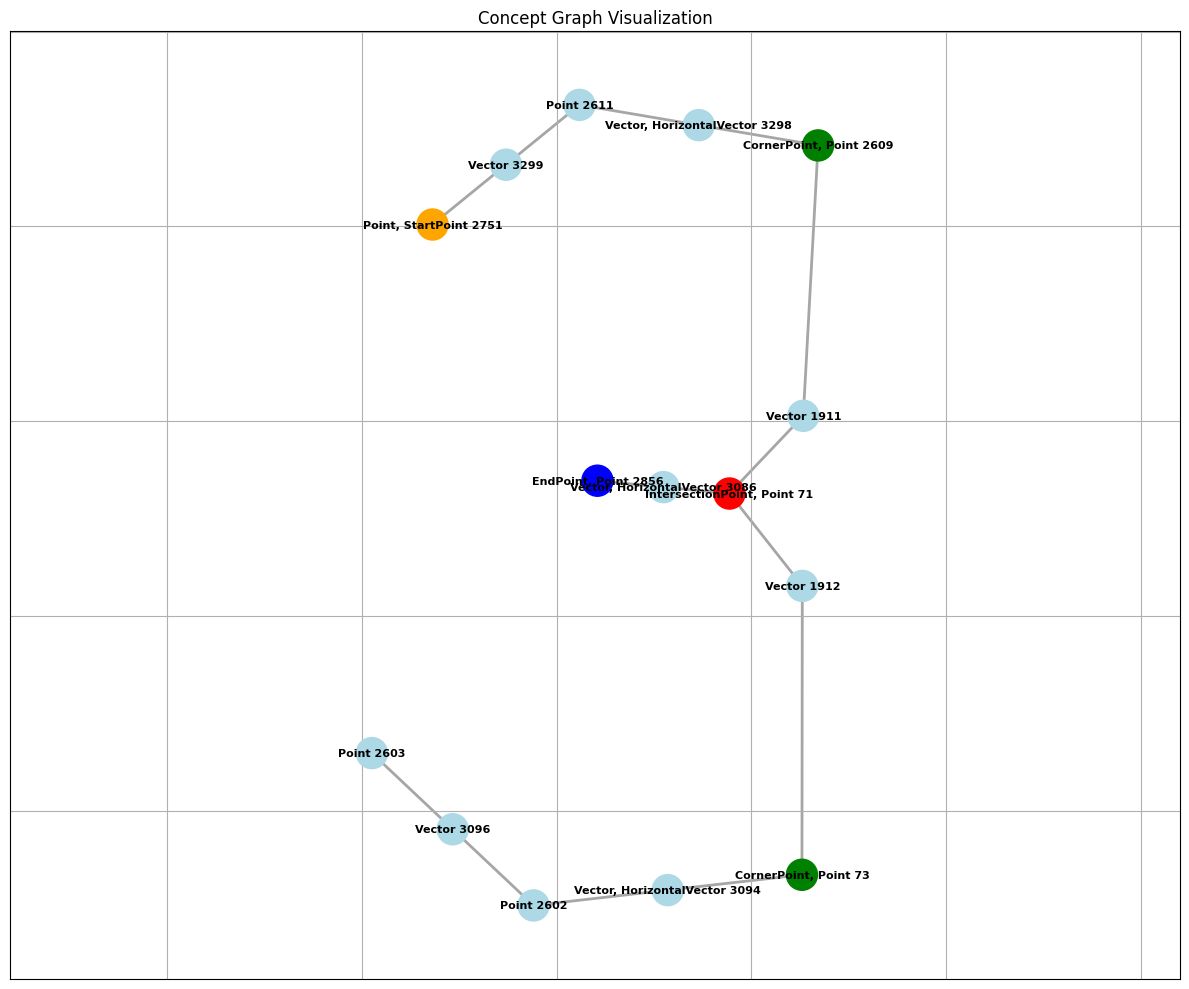

In [4]:
visualize_concept(concept_graph)

In [5]:
# Printing the graph properties per node
for node in concept_graph.nodes():
    print(f"Node {node}: {concept_graph.nodes[node]}")

# Create a directory for saved graphs if it doesn't exist
save_dir = "saved_graphs"
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

# Convert the graph to a JSON-serializable format
graph_data = nx.node_link_data(concept_graph)

# Save the graph with a descriptive filename
json_filename = os.path.join(save_dir, "concept_graph.json")
with open(json_filename, "w") as f:
    json.dump(graph_data, f, indent=2)

print(f"Graph saved to {json_filename} in JSON format")



Node 4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:2751: {'labels': ['Point', 'StartPoint'], 'corner_points_count': 3, 'cycle_count': 0, 'normalized_x': {'min': -0.56, 'max': -0.35, 'type': 'range', 'center': -0.4102992700926685}, 'quadrant_change_count': 5, 'x': {'min': 38.835395413825225, 'max': 93.4056574819968, 'type': 'range', 'center': 67.24411919832558}, 'contour_type': 'OPEN', 'normalized_y': {'min': -0.62, 'max': -0.52, 'type': 'range', 'center': -0.5897654090401684}, 'session_id': '3_1', 'monotony': 'NON_MONOTONIC', 'relative_distance': {'min': 0.71, 'max': 0.77, 'type': 'range', 'center': 0.7204126936826732}, 'segments': ['top', 'left'], 'vectors_count': 9, 'intersection_points_count': 1, 'endpoints_count': 2, 'y': {'min': 31.47349902288081, 'max': 97.69843226514436, 'type': 'range', 'center': 79.817277700877}}
Node 4:9e1c8335-dc1b-46bc-b817-da0e4e40f10b:3299: {'labels': ['Vector'], 'y1': {'min': 20.015782900828565, 'max': 84.63421797671363, 'type': 'range', 'center': 67.5303697174

/Users/mlapin/anaconda3/envs/natural_agi/lib/python3.11/site-packages/networkx/readwrite/json_graph/node_link.py:142: FutureWarning: 
The default value will be `edges="edges" in NetworkX 3.6.

To make this warning go away, explicitly set the edges kwarg, e.g.:

  nx.node_link_data(G, edges="links") to preserve current behavior, or
  nx.node_link_data(G, edges="edges") for forward compatibility.
  warnings.warn(
